# Manhattan Terrain Data

This notebook retrieves and processes public elevation data for Manhattan.

## Data Source

- Provider: City of New York and New York State GIS
- Dataset: 2017 NYC Topobathymetric LiDAR DEM
- Surface type: Bare-earth elevation
- Original resolution: 1 US survey foot
- Horizontal reference: New York Long Island State Plane
- Vertical reference: NAVD88
- Access: Public

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

buildings_path = (
    project_root
    / "data"
    / "processed"
    / "manhattan_building_footprints_processed.gpkg"
)

buildings = gpd.read_file(
    buildings_path,
    layer="building_footprints"
)

print("Rows and columns:", buildings.shape)
print("Coordinate system:", buildings.crs)
print("File exists:", buildings_path.exists())

Rows and columns: (45195, 23)
Coordinate system: EPSG:2263
File exists: True


In [3]:
from urllib.parse import urlencode

## Retrieve the DEM Tile Index

The tile index identifies the locations and download links of the 2017 DEM files.

In [4]:
tile_index_base_url = (
    "https://elevation.its.ny.gov/arcgis/rest/services/"
    "Dem_Indexes/FeatureServer/0/query"
)

tile_index_params = {
    "where": "1=1",
    "outFields": (
        "FILENAME,SIZE_,DEM_COLLEC,"
        "YEAR,DIRECT_DL"
    ),
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson"
}

tile_index_url = (
    f"{tile_index_base_url}?"
    f"{urlencode(tile_index_params)}"
)

dem_tiles = gpd.read_file(tile_index_url)

print("Rows and columns:", dem_tiles.shape)
print("Coordinate system:", dem_tiles.crs)
print("Columns:", dem_tiles.columns.tolist())

dem_tiles.head()

Rows and columns: (32, 6)
Coordinate system: EPSG:4326
Columns: ['FILENAME', 'SIZE_', 'DEM_COLLEC', 'YEAR', 'DIRECT_DL', 'geometry']


,FILENAME,SIZE_,DEM_COLLEC,YEAR,DIRECT_DL,geometry
0,be_NYC_001.tif,81613409.0,NYC,2017,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...,"POLYGON ((-74.21304 40.49881, -74.21307 40.509..."
1,be_NYC_002.tif,1558852.0,NYC,2017,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...,"POLYGON ((-74.21304 40.49881, -74.20502 40.505..."
2,be_NYC_004.tif,280444227.0,NYC,2017,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...,"POLYGON ((-74.21307 40.50957, -74.21326 40.568..."
3,be_NYC_005.tif,878255974.0,NYC,2017,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...,"POLYGON ((-74.1232 40.52563, -74.1233 40.57833..."
4,be_NYC_006.tif,174310192.0,NYC,2017,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...,"POLYGON ((-74.1232 40.52563, -74.09475 40.5467..."


In [5]:
from shapely.geometry import box

## Select DEM Tiles for Manhattan

Select only the DEM tiles that intersect the geographic extent of the Manhattan building footprints.

In [6]:
dem_tiles_projected = dem_tiles.to_crs(
    buildings.crs
)

building_bounds = buildings.total_bounds

manhattan_bounding_box = box(
    building_bounds[0],
    building_bounds[1],
    building_bounds[2],
    building_bounds[3]
)

manhattan_tiles = dem_tiles_projected.loc[
    dem_tiles_projected.intersects(
        manhattan_bounding_box
    )
].copy()

manhattan_tiles["size_mb"] = (
    manhattan_tiles["SIZE_"] / 1_000_000
)

print("Building bounds:")
print(building_bounds)

print(
    "\nNumber of intersecting tiles:",
    len(manhattan_tiles)
)

print(
    "Estimated total download size:",
    round(manhattan_tiles["size_mb"].sum(), 2),
    "MB"
)

manhattan_tiles[
    ["FILENAME", "size_mb", "DIRECT_DL"]
]

Building bounds:
[ 971135.9437198   188580.04971045 1010069.14941516  259423.2788914 ]

Number of intersecting tiles: 9
Estimated total download size: 5613.36 MB


,FILENAME,size_mb,DIRECT_DL
12,be_NYC_030.tif,962.539990,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
15,be_NYC_033.tif,0.264162,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
16,be_NYC_034.tif,819.089366,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
22,be_NYC_019.tif,30.678870,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
23,be_NYC_020.tif,819.589445,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
24,be_NYC_021.tif,1037.106610,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
27,be_NYC_025.tif,673.930486,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
28,be_NYC_026.tif,998.951130,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...
31,be_NYC_029.tif,271.208716,https://gisdata.ny.gov/elevation/DEM/NYC_TopoB...


In [7]:
# Official NYC Borough Boundaries dataset
borough_endpoint = (
    "https://data.cityofnewyork.us/resource/"
    "gthc-hcne.geojson"
)

borough_params = {
    "$where": "borocode = 1"
}

borough_url = (
    f"{borough_endpoint}?{urlencode(borough_params)}"
)

# Download the Manhattan boundary
manhattan_boundary = gpd.read_file(borough_url)

# NOAA needs the upload boundary in latitude/longitude
# First project to feet, add a 500-foot buffer,
# then convert back to EPSG:4326.
download_aoi = manhattan_boundary.to_crs("EPSG:2263").copy()
download_aoi["geometry"] = download_aoi.geometry.buffer(500)
download_aoi = download_aoi.to_crs("EPSG:4326")

# Save only the name and geometry
aoi_path = (
    project_root
    / "data"
    / "raw"
    / "manhattan_dem_aoi.geojson"
)

download_aoi[
    ["boroname", "geometry"]
].to_file(
    aoi_path,
    driver="GeoJSON",
    index=False
)

print("Rows:", len(download_aoi))
print("Borough:", download_aoi["boroname"].tolist())
print("CRS:", download_aoi.crs)
print("Geometry:", download_aoi.geometry.geom_type.tolist())
print("File exists:", aoi_path.exists())
print("Saved to:", aoi_path)

Rows: 1
Borough: ['Manhattan']
CRS: EPSG:4326
Geometry: ['MultiPolygon']
File exists: True
Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\raw\manhattan_dem_aoi.geojson


In [8]:
import json

# Split Manhattan's MultiPolygon into individual Polygon features
aoi_parts = (
    download_aoi
    .explode(index_parts=False)
    .reset_index(drop=True)
)

# Build a minimal GeoJSON accepted by NOAA
geojson_data = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": geometry.__geo_interface__
        }
        for geometry in aoi_parts.geometry
    ]
}

# Overwrite the previous file
with aoi_path.open("w", encoding="utf-8") as file:
    json.dump(geojson_data, file)

print("Top-level fields:", list(geojson_data.keys()))
print("Number of polygons:", len(aoi_parts))
print("Geometry types:", aoi_parts.geometry.geom_type.unique())
print("File exists:", aoi_path.exists())

Top-level fields: ['type', 'features']
Number of polygons: 12
Geometry types: <StringArray>
['Polygon']
Length: 1, dtype: str
File exists: True


### NOAA Data Access

The Manhattan DEM was requested manually through the NOAA Digital
Coast Data Access Viewer. A single buffered polygon was used because
the viewer accepted only one AOI geometry.

The downloaded GeoTIFF tiles were clipped by NOAA to the submitted AOI
and saved locally under:

`data/raw/noaa_dem_2017/extracted/`

Raw DEM files are excluded from Git because of their size. After
download, the DEM was clipped again to the official Manhattan borough
boundary with a 500-foot processing buffer.

In [9]:
import sys
import geopandas as gpd
import rasterio

print("Python:", sys.executable)
print("GeoPandas:", gpd.__version__)
print("Rasterio:", rasterio.__version__)

Python: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\.venv\Scripts\python.exe
GeoPandas: 1.1.4
Rasterio: 1.5.1


## Inspect Local NOAA DEM Files

In [10]:
from pathlib import Path

# Identify the project root whether the notebook starts in the
# repository root or inside the notebooks folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

dem_directory = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "noaa_dem_2017"
    / "extracted"
)

# Search all nested folders because NOAA may add another directory layer.
dem_files = sorted(dem_directory.rglob("*.tif"))

print("DEM directory:", dem_directory)
print("Number of TIFF files:", len(dem_files))

for path in dem_files:
    size_mb = path.stat().st_size / (1024**2)
    print(f"{path.name}: {size_mb:.2f} MB")

DEM directory: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\raw\noaa_dem_2017\extracted
Number of TIFF files: 7
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR0_C0.tif: 273.50 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR0_C1.tif: 4.03 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR1_C0.tif: 315.17 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR1_C1.tif: 203.12 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR2_C0.tif: 39.91 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR2_C1.tif: 353.59 MB
nyc_topobathy_dem_hydroEnforced_2017_J1443530tR3_C1.tif: 52.09 MB


## Validate NOAA DEM Tiles

In [11]:
import pandas as pd
import rasterio

tile_metadata = []

for path in dem_files:
    with rasterio.open(path) as source:
        tile_metadata.append(
            {
                "filename": path.name,
                "crs": source.crs.to_string(),
                "width": source.width,
                "height": source.height,
                "resolution_x": source.res[0],
                "resolution_y": source.res[1],
                "bands": source.count,
                "dtype": source.dtypes[0],
                "nodata": source.nodata,
            }
        )

tile_metadata = pd.DataFrame(tile_metadata)
tile_metadata

,filename,crs,width,height,resolution_x,resolution_y,bands,dtype,nodata
0,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,22359,22358,1.0,1.0,1,float32,-999999.0
1,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,1700,3249,1.0,1.0,1,float32,-999999.0
2,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,17535,22360,1.0,1.0,1,float32,-999999.0
3,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,11646,22360,1.0,1.0,1,float32,-999999.0
4,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,6553,12567,1.0,1.0,1,float32,-999999.0
5,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,13099,22360,1.0,1.0,1,float32,-999999.0
6,nyc_topobathy_dem_hydroEnforced_2017_J1443530t...,EPSG:6539,9124,5289,1.0,1.0,1,float32,-999999.0


## Merge and Resample DEM Tiles

In [12]:
from contextlib import ExitStack

import numpy as np
from rasterio.enums import Resampling
from rasterio.merge import merge

# Exact conversion: one US survey foot equals 1200 / 3937 metres.
US_SURVEY_FOOT_TO_METER = 1200 / 3937

TARGET_RESOLUTION_M = 5.0
target_resolution_ft = (
    TARGET_RESOLUTION_M / US_SURVEY_FOOT_TO_METER
)

source_nodata = float(tile_metadata["nodata"].iloc[0])

# ExitStack opens all seven tiles and guarantees that every file is closed.
with ExitStack() as stack:
    sources = [
        stack.enter_context(rasterio.open(path))
        for path in dem_files
    ]

    dem_mosaic_ft, dem_transform = merge(
        sources,
        res=(target_resolution_ft, target_resolution_ft),
        nodata=source_nodata,
        dtype="float32",
        resampling=Resampling.average,
        masked=True,
        target_aligned_pixels=True,
    )

dem_band_ft = dem_mosaic_ft[0]
valid_mask = ~np.ma.getmaskarray(dem_band_ft)

print("Target resolution:", target_resolution_ft, "US survey feet")
print("Output shape:", dem_band_ft.shape)
print("Valid pixels:", valid_mask.sum())
print("Approximate memory:", round(dem_mosaic_ft.nbytes / 1024**2, 2), "MB")

if valid_mask.any():
    print(
        "Elevation range:",
        round(float(dem_band_ft.min()), 2),
        "to",
        round(float(dem_band_ft.max()), 2),
        "feet NAVD88",
    )
else:
    raise ValueError("The merged DEM contains no valid elevation pixels.")

Target resolution: 16.40416666666667 US survey feet
Output shape: (4412, 2178)
Valid pixels: 3486555
Approximate memory: 36.66 MB
Elevation range: -35.04 to 265.85 feet NAVD88


## Convert Elevation to Metres and Save

In [13]:
OUTPUT_NODATA = -9999.0

# Create a regular float32 array and preserve NoData locations.
dem_band_m = np.full(
    dem_band_ft.shape,
    OUTPUT_NODATA,
    dtype=np.float32,
)

# Convert only valid elevation pixels from US survey feet to metres.
dem_band_m[valid_mask] = (
    dem_band_ft.data[valid_mask]
    * US_SURVEY_FOOT_TO_METER
)

output_dem_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "manhattan_dem_5m_navd88_m_epsg6539.tif"
)

output_dem_path.parent.mkdir(parents=True, exist_ok=True)

output_profile = {
    "driver": "GTiff",
    "height": dem_band_m.shape[0],
    "width": dem_band_m.shape[1],
    "count": 1,
    "dtype": "float32",
    "crs": "EPSG:6539",
    "transform": dem_transform,
    "nodata": OUTPUT_NODATA,
    "compress": "deflate",
    "predictor": 3,
    "tiled": True,
    "blockxsize": 512,
    "blockysize": 512,
}

with rasterio.open(
    output_dem_path,
    "w",
    **output_profile,
) as destination:
    destination.write(dem_band_m, 1)

    destination.update_tags(
        source="2017 NYC Topobathy Lidar Hydroenforced DEM",
        horizontal_crs="EPSG:6539",
        elevation_units="metres",
        vertical_datum="NAVD88",
        processing="Merged and averaged from 1 ft to 5 m resolution",
    )

print("Saved to:", output_dem_path)
print("File exists:", output_dem_path.exists())
print(
    "File size:",
    round(output_dem_path.stat().st_size / 1024**2, 2),
    "MB",
)

Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_dem_5m_navd88_m_epsg6539.tif
File exists: True
File size: 9.07 MB


## Validate and Visualize the Processed DEM

In [14]:
with rasterio.open(output_dem_path) as source:
    saved_dem = source.read(1, masked=True)
    saved_bounds = source.bounds

    print("CRS:", source.crs)
    print("Shape:", saved_dem.shape)
    print("Resolution:", source.res)
    print("NoData:", source.nodata)
    print("Valid pixels:", saved_dem.count())
    print(
        "Elevation range:",
        round(float(saved_dem.min()), 2),
        "to",
        round(float(saved_dem.max()), 2),
        "metres NAVD88",
    )

CRS: EPSG:6539
Shape: (4412, 2178)
Resolution: (16.40416666666667, 16.40416666666667)
NoData: -9999.0
Valid pixels: 3486555
Elevation range: -10.68 to 81.03 metres NAVD88


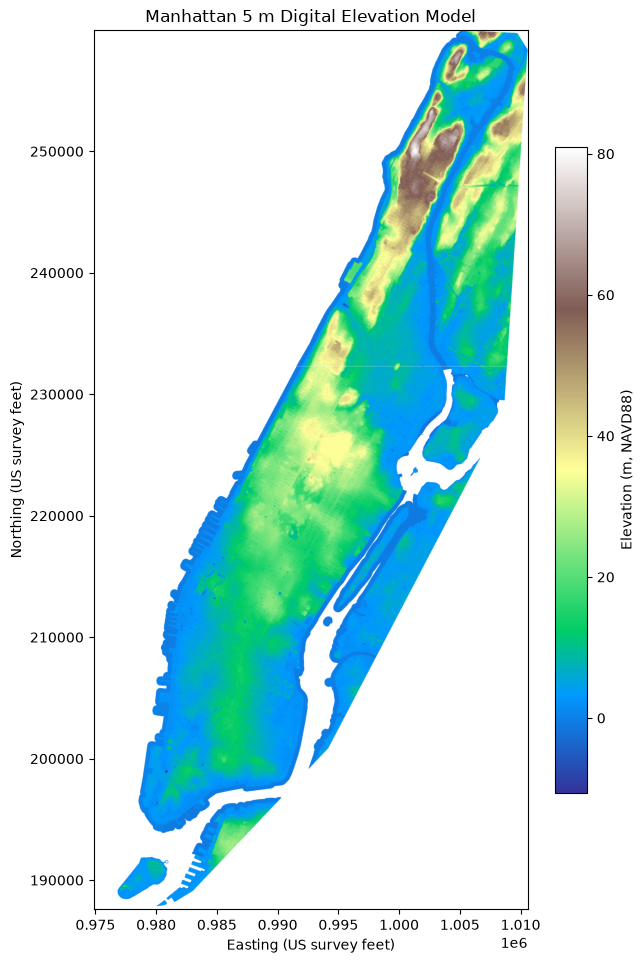

Figure saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_dem_5m.png


In [15]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(7, 12))

image = axis.imshow(
    saved_dem,
    cmap="terrain",
    extent=[
        saved_bounds.left,
        saved_bounds.right,
        saved_bounds.bottom,
        saved_bounds.top,
    ],
    origin="upper",
)

colorbar = figure.colorbar(
    image,
    ax=axis,
    shrink=0.7,
)

colorbar.set_label("Elevation (m, NAVD88)")

axis.set_title("Manhattan 5 m Digital Elevation Model")
axis.set_xlabel("Easting (US survey feet)")
axis.set_ylabel("Northing (US survey feet)")

output_figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "manhattan_dem_5m.png"
)

figure.savefig(
    output_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", output_figure_path)

## Mask DEM to the Manhattan Analysis Area

In [16]:
from urllib.parse import urlencode

from rasterio.mask import mask
from shapely.geometry import mapping

# Retrieve the official Manhattan borough boundary.
borough_query = urlencode(
    {
        "$where": "boroname='Manhattan'",
        "$limit": 10,
    }
)

borough_url = (
    "https://data.cityofnewyork.us/resource/"
    f"gthc-hcne.geojson?{borough_query}"
)

manhattan_boundary = gpd.read_file(borough_url)
manhattan_boundary = manhattan_boundary.to_crs("EPSG:6539")

# Keep a 500-foot terrain buffer for edge calculations.
# Dissolve preserves separate polygons; it does not create a convex hull.
analysis_boundary = manhattan_boundary.copy()
analysis_boundary["geometry"] = (
    analysis_boundary.geometry.buffer(500)
)
analysis_boundary = analysis_boundary.dissolve()

analysis_dem_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "manhattan_dem_5m_analysis_area_navd88_m_epsg6539.tif"
)

with rasterio.open(output_dem_path) as source:
    clipped_dem, clipped_transform = mask(
        source,
        [
            mapping(geometry)
            for geometry in analysis_boundary.geometry
        ],
        crop=True,
        nodata=OUTPUT_NODATA,
        filled=True,
    )

    clipped_profile = source.profile.copy()
    source_tags = source.tags()

clipped_profile.update(
    height=clipped_dem.shape[1],
    width=clipped_dem.shape[2],
    transform=clipped_transform,
)

with rasterio.open(
    analysis_dem_path,
    "w",
    **clipped_profile,
) as destination:
    destination.write(clipped_dem)
    destination.update_tags(
        **source_tags,
        analysis_area="Official Manhattan boundary with 500 ft buffer",
    )

print("Saved to:", analysis_dem_path)
print(
    "File size:",
    round(analysis_dem_path.stat().st_size / 1024**2, 2),
    "MB",
)

Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_dem_5m_analysis_area_navd88_m_epsg6539.tif
File size: 8.59 MB


In [17]:
with rasterio.open(analysis_dem_path) as source:
    analysis_dem = source.read(1, masked=True)
    analysis_bounds = source.bounds

    print("CRS:", source.crs)
    print("Shape:", analysis_dem.shape)
    print("Resolution:", source.res)
    print("Valid pixels:", analysis_dem.count())
    print(
        "Elevation range:",
        round(float(analysis_dem.min()), 2),
        "to",
        round(float(analysis_dem.max()), 2),
        "metres NAVD88",
    )

CRS: EPSG:6539
Shape: (4412, 2178)
Resolution: (16.40416666666667, 16.40416666666667)
Valid pixels: 2727439
Elevation range: -10.68 to 81.03 metres NAVD88


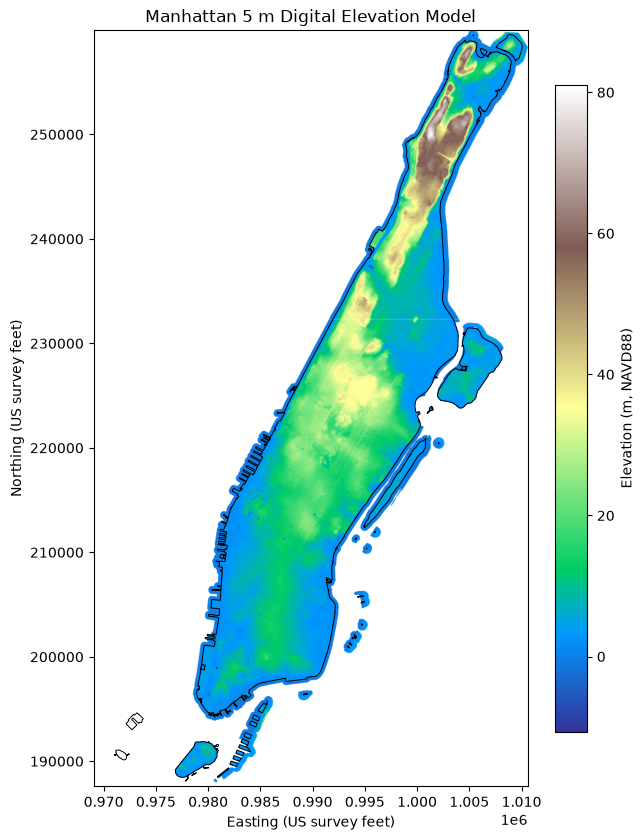

Figure saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_dem_5m.png


In [18]:
figure, axis = plt.subplots(figsize=(7, 12))

image = axis.imshow(
    analysis_dem,
    cmap="terrain",
    extent=[
        analysis_bounds.left,
        analysis_bounds.right,
        analysis_bounds.bottom,
        analysis_bounds.top,
    ],
    origin="upper",
)

# Overlay the actual Manhattan borough boundary.
manhattan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=0.7,
)

colorbar = figure.colorbar(
    image,
    ax=axis,
    shrink=0.7,
)

colorbar.set_label("Elevation (m, NAVD88)")

axis.set_title("Manhattan 5 m Digital Elevation Model")
axis.set_xlabel("Easting (US survey feet)")
axis.set_ylabel("Northing (US survey feet)")

output_figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "manhattan_dem_5m.png"
)

figure.savefig(
    output_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", output_figure_path)

## Check DEM Coverage of Manhattan Buildings

In [19]:
processed_data_directory = (
    PROJECT_ROOT / "data" / "processed"
)

building_candidates = sorted(
    processed_data_directory.glob(
        "manhattan_building_footprints*.gpkg"
    )
)

if len(building_candidates) != 1:
    raise ValueError(
        "Expected exactly one processed building GeoPackage, "
        f"but found {len(building_candidates)}."
    )

building_path = building_candidates[0]
buildings = gpd.read_file(building_path)

# Reproject buildings to the DEM coordinate system.
buildings_6539 = buildings.to_crs("EPSG:6539")

# representative_point() guarantees a point inside each footprint;
# a centroid can occasionally fall outside an irregular polygon.
building_points = (
    buildings_6539.geometry.representative_point()
)

sample_coordinates = [
    (point.x, point.y)
    for point in building_points
]

with rasterio.open(analysis_dem_path) as source:
    sampled_elevations = np.array(
        [
            value[0]
            for value in source.sample(sample_coordinates)
        ],
        dtype=np.float32,
    )

    dem_nodata = source.nodata

valid_elevation_mask = (
    np.isfinite(sampled_elevations)
    & (sampled_elevations != dem_nodata)
)

covered_buildings = int(valid_elevation_mask.sum())
total_buildings = len(buildings)
coverage_percentage = (
    covered_buildings / total_buildings * 100
)

print("Total buildings:", f"{total_buildings:,}")
print("Buildings covered by DEM:", f"{covered_buildings:,}")
print(
    "Buildings without DEM elevation:",
    f"{total_buildings - covered_buildings:,}",
)
print("DEM coverage:", f"{coverage_percentage:.2f}%")

Total buildings: 45,195
Buildings covered by DEM: 45,151
Buildings without DEM elevation: 44
DEM coverage: 99.90%


## Investigate Buildings Without DEM Coverage

In [20]:
missing_buildings = buildings_6539.loc[
    ~valid_elevation_mask
].copy()

# Replace polygons with the exact points used to sample the DEM.
missing_buildings.geometry = building_points.loc[
    ~valid_elevation_mask
]

inspection_columns = [
    column
    for column in [
        "bin",
        "feature_code",
        "geom_source",
        "ground_elevation",
        "height_roof",
        "geometry",
    ]
    if column in missing_buildings.columns
]

print("Missing buildings:", len(missing_buildings))
display(missing_buildings[inspection_columns].head(20))

Missing buildings: 44


,bin,feature_code,geom_source,ground_elevation,height_roof,geometry
1942,1089253,2100,Other (Manual),8.0,18.000000,POINT (972284.281 193652.582)
1964,1087223,2100,Other (Manual),7.0,21.000000,POINT (971209.108 190924.381)
1965,1087227,2100,Other (Manual),7.0,26.000000,POINT (971219.857 190840.955)
1966,1087229,2100,Other (Manual),12.0,13.000000,POINT (971752.184 190614.286)
2083,1090370,2100,Other (Manual),9.0,53.000000,POINT (972796.336 193187.086)
2084,1090371,2100,Other (Manual),9.0,53.000000,POINT (972686.313 193108.185)
2085,1090372,2100,Other (Manual),9.0,53.000000,POINT (972594.207 193203.567)
2086,1090369,2100,Other (Manual),9.0,53.000000,POINT (972705.453 193189.589)
2087,1090368,2100,Other (Manual),12.0,87.000000,POINT (972687.912 193847.889)
2091,1090052,2100,Other (Manual),12.0,87.000000,POINT (972916.459 193609.054)


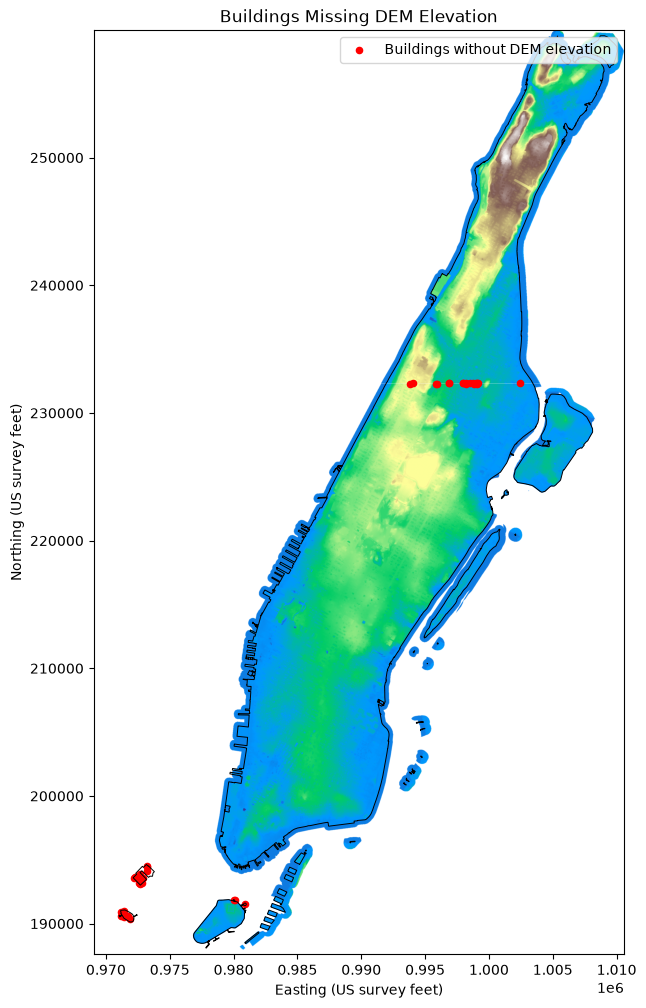

In [21]:
figure, axis = plt.subplots(figsize=(7, 12))

axis.imshow(
    analysis_dem,
    cmap="terrain",
    extent=[
        analysis_bounds.left,
        analysis_bounds.right,
        analysis_bounds.bottom,
        analysis_bounds.top,
    ],
    origin="upper",
)

manhattan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=0.7,
)

missing_buildings.plot(
    ax=axis,
    color="red",
    markersize=20,
    label="Buildings without DEM elevation",
)

axis.set_title("Buildings Missing DEM Elevation")
axis.set_xlabel("Easting (US survey feet)")
axis.set_ylabel("Northing (US survey feet)")
axis.legend()

plt.show()

## Repair Narrow NoData Seams

In [22]:
from rasterio.features import geometry_mask
from rasterio.fill import fillnodata

with rasterio.open(analysis_dem_path) as source:
    dem_before_fill = source.read(1, masked=True)
    final_profile = source.profile.copy()
    final_tags = source.tags()
    final_transform = source.transform

original_missing_mask = np.ma.getmaskarray(
    dem_before_fill
)

# Rasterio uses values greater than zero to identify valid source pixels.
valid_source_mask = (
    ~original_missing_mask
).astype(np.uint8)

# Fill only narrow gaps within three 5 m pixels.
filled_dem = fillnodata(
    image=dem_before_fill.filled(
        OUTPUT_NODATA
    ).astype(np.float32),
    mask=valid_source_mask,
    max_search_distance=3,
    smoothing_iterations=0,
)

# Reapply the buffered Manhattan boundary because interpolation can
# temporarily extend a few pixels beyond the mask edge.
inside_analysis_area = geometry_mask(
    [
        mapping(geometry)
        for geometry in analysis_boundary.geometry
    ],
    out_shape=filled_dem.shape,
    transform=final_transform,
    invert=True,
)

filled_dem[~inside_analysis_area] = OUTPUT_NODATA

final_valid_mask = (
    np.isfinite(filled_dem)
    & (filled_dem != OUTPUT_NODATA)
)

pixels_repaired = (
    original_missing_mask
    & final_valid_mask
    & inside_analysis_area
).sum()

final_dem_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "manhattan_dem_5m_final_navd88_m_epsg6539.tif"
)

with rasterio.open(
    final_dem_path,
    "w",
    **final_profile,
) as destination:
    destination.write(filled_dem, 1)
    destination.update_tags(
        **final_tags,
        gap_fill_method="Rasterio fillnodata",
        gap_fill_max_distance="15 metres",
    )

print("Pixels repaired:", f"{pixels_repaired:,}")
print("Saved to:", final_dem_path)
print(
    "File size:",
    round(final_dem_path.stat().st_size / 1024**2, 2),
    "MB",
)

Pixels repaired: 38,969
Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_dem_5m_final_navd88_m_epsg6539.tif
File size: 8.65 MB


In [23]:
with rasterio.open(final_dem_path) as source:
    final_sampled_elevations = np.array(
        [
            value[0]
            for value in source.sample(sample_coordinates)
        ],
        dtype=np.float32,
    )

    final_nodata = source.nodata

final_valid_elevation_mask = (
    np.isfinite(final_sampled_elevations)
    & (final_sampled_elevations != final_nodata)
)

final_covered_buildings = int(
    final_valid_elevation_mask.sum()
)

final_missing_buildings = (
    total_buildings - final_covered_buildings
)

final_coverage_percentage = (
    final_covered_buildings
    / total_buildings
    * 100
)

print("Total buildings:", f"{total_buildings:,}")
print(
    "Buildings covered after repair:",
    f"{final_covered_buildings:,}",
)
print(
    "Buildings still without DEM:",
    f"{final_missing_buildings:,}",
)
print(
    "Final DEM coverage:",
    f"{final_coverage_percentage:.2f}%",
)

Total buildings: 45,195
Buildings covered after repair: 45,169
Buildings still without DEM: 26
Final DEM coverage: 99.94%


In [24]:
remaining_missing_buildings = buildings_6539.loc[
    ~final_valid_elevation_mask
].copy()

remaining_missing_buildings.geometry = building_points.loc[
    ~final_valid_elevation_mask
]

ground_elevation_available = (
    remaining_missing_buildings[
        "ground_elevation"
    ].notna().sum()
)

print(
    "Remaining buildings:",
    len(remaining_missing_buildings),
)
print(
    "With source ground elevation:",
    ground_elevation_available,
)
print(
    "Without any ground elevation:",
    len(remaining_missing_buildings)
    - ground_elevation_available,
)

display(
    remaining_missing_buildings[
        [
            "bin",
            "ground_elevation",
            "feature_code",
            "geometry",
        ]
    ]
)

Remaining buildings: 26
With source ground elevation: 25
Without any ground elevation: 1


,bin,ground_elevation,feature_code,geometry
1942,1089253,8.0,2100,POINT (972284.281 193652.582)
1964,1087223,7.0,2100,POINT (971209.108 190924.381)
1965,1087227,7.0,2100,POINT (971219.857 190840.955)
1966,1087229,12.0,2100,POINT (971752.184 190614.286)
2083,1090370,9.0,2100,POINT (972796.336 193187.086)
2084,1090371,9.0,2100,POINT (972686.313 193108.185)
2085,1090372,9.0,2100,POINT (972594.207 193203.567)
2086,1090369,9.0,2100,POINT (972705.453 193189.589)
2087,1090368,12.0,2100,POINT (972687.912 193847.889)
2091,1090052,12.0,2100,POINT (972916.459 193609.054)


In [25]:
buildings_terrain = buildings_6539.copy()

# Store valid DEM elevations; convert NoData to NaN.
buildings_terrain["dem_elevation_m"] = (
    final_sampled_elevations
)

buildings_terrain.loc[
    ~final_valid_elevation_mask,
    "dem_elevation_m",
] = np.nan

# Record NYC ground elevation as a separate fallback field.
buildings_terrain["fallback_ground_elevation_m"] = np.nan

fallback_mask = (
    ~final_valid_elevation_mask
    & buildings_terrain["ground_elevation"].notna()
)

buildings_terrain.loc[
    fallback_mask,
    "fallback_ground_elevation_m",
] = (
    buildings_terrain.loc[
        fallback_mask,
        "ground_elevation",
    ]
    * US_SURVEY_FOOT_TO_METER
)

# Eligibility requires continuous DEM coverage because later features
# include slope and flow accumulation, not elevation alone.
buildings_terrain["terrain_model_eligible"] = (
    final_valid_elevation_mask
)

buildings_terrain["terrain_exclusion_reason"] = pd.NA

buildings_terrain.loc[
    ~final_valid_elevation_mask,
    "terrain_exclusion_reason",
] = "No valid NOAA DEM coverage"

print(
    buildings_terrain[
        "terrain_model_eligible"
    ].value_counts()
)

print(
    "Fallback elevations available:",
    int(fallback_mask.sum()),
)

terrain_model_eligible
True     45169
False       26
Name: count, dtype: int64
Fallback elevations available: 25
